<a href="https://www.kaggle.com/code/aamir28/titanic-30-day-competition-notebook?scriptVersionId=330039224" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Titanic — 30-Day Kaggle Competition Notebook

A progressive study of the Titanic dataset, adding one new technique per day.
Each section is self-contained: run the **Setup** cell first, then any Day cell independently.

**Days covered:** 1 (Baseline RF) → 2 (FamilySize) → 3 (Title) → 4 (Logistic Regression) → 5 (XGBoost) → 6 (AgeGroup)

**Planned:** Days 7–30 continue with FarePerPerson, hyperparameter tuning, ensembles, neural nets, and more.

## 0 · Setup — Install & Import

In [1]:
# Run once to install optional libraries
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])


0

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('All imports OK')

All imports OK


## 1 · Load Data

In [3]:
# Update these paths if your files are elsewhere
TRAIN_PATH = '/kaggle/input/competitions/titanic/train.csv'
TEST_PATH  = '/kaggle/input/competitions/titanic/test.csv'

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

print(f'Train: {train_raw.shape}  |  Test: {test_raw.shape}')
train_raw.head()

Train: (891, 12)  |  Test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


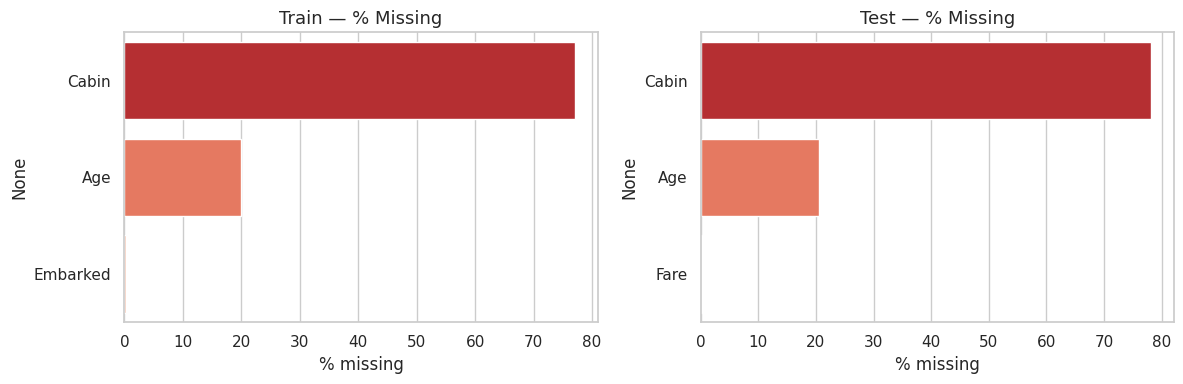

In [4]:
# Missing value overview
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes, [train_raw, test_raw], ['Train', 'Test']):
    missing = df.isnull().sum() / len(df) * 100
    missing = missing[missing > 0].sort_values(ascending=False)
    sns.barplot(x=missing.values, y=missing.index, ax=ax, palette='Reds_r')
    ax.set_title(f'{title} — % Missing', fontsize=13)
    ax.set_xlabel('% missing')
plt.tight_layout()
plt.show()

## 2 · Exploratory Data Analysis

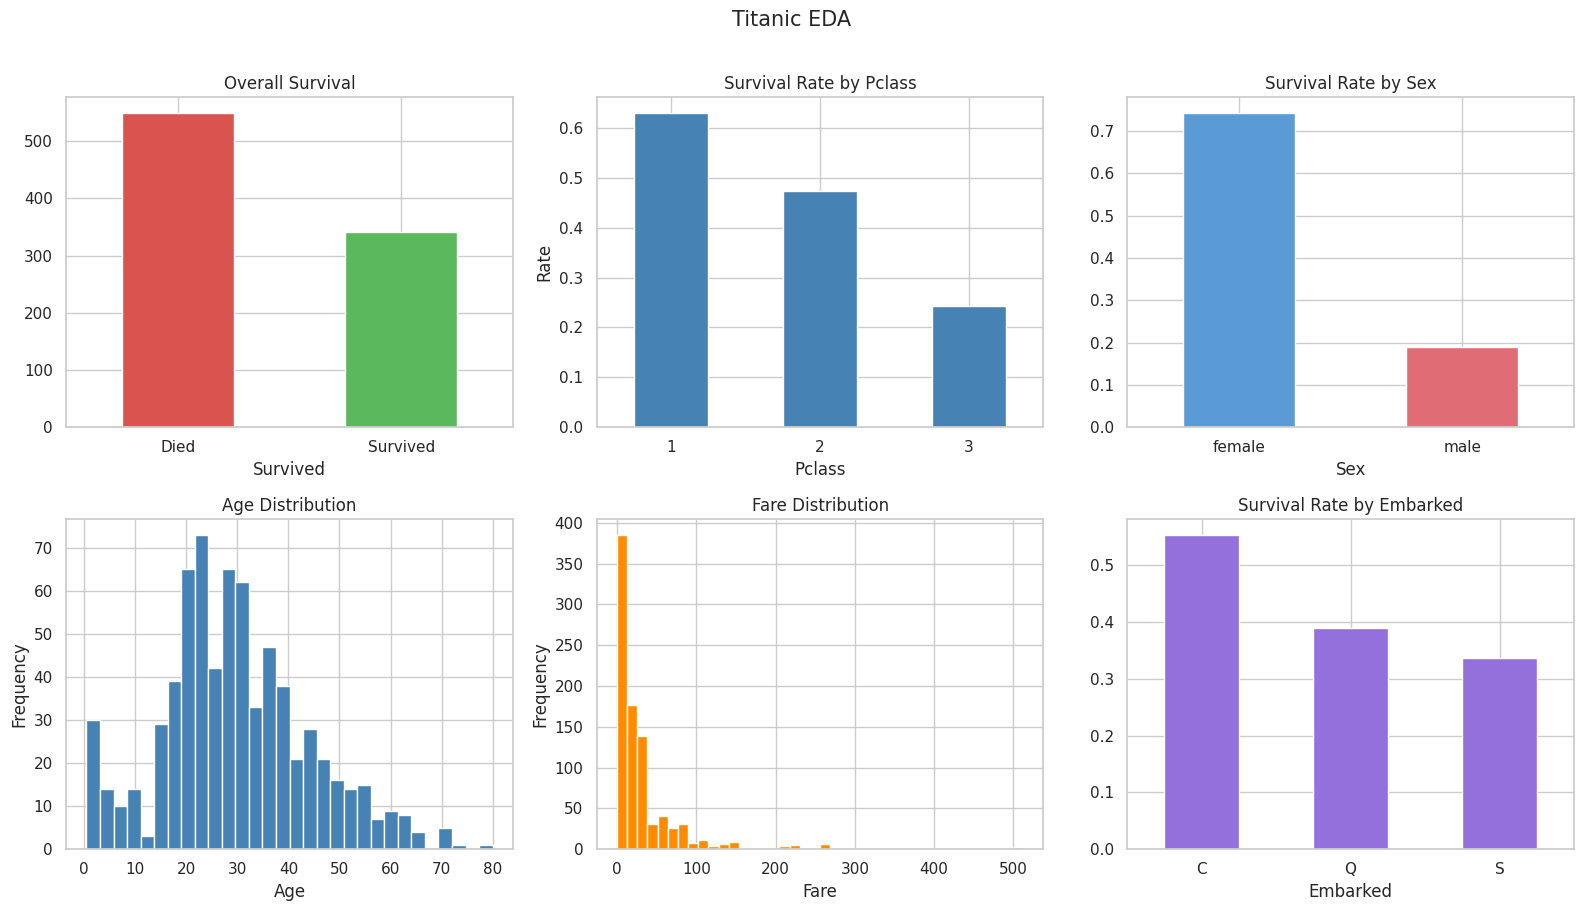

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Survival overall
train_raw['Survived'].value_counts().plot.bar(ax=axes[0,0], color=['#d9534f','#5cb85c'], rot=0)
axes[0,0].set_title('Overall Survival'); axes[0,0].set_xticklabels(['Died','Survived'])

# Survival by Pclass
train_raw.groupby('Pclass')['Survived'].mean().plot.bar(ax=axes[0,1], color='steelblue', rot=0)
axes[0,1].set_title('Survival Rate by Pclass'); axes[0,1].set_ylabel('Rate')

# Survival by Sex
train_raw.groupby('Sex')['Survived'].mean().plot.bar(ax=axes[0,2], color=['#5b9bd5','#e06c75'], rot=0)
axes[0,2].set_title('Survival Rate by Sex')

# Age distribution
train_raw['Age'].plot.hist(ax=axes[1,0], bins=30, color='steelblue', edgecolor='white')
axes[1,0].set_title('Age Distribution'); axes[1,0].set_xlabel('Age')

# Fare distribution (log scale)
train_raw['Fare'].plot.hist(ax=axes[1,1], bins=40, color='darkorange', edgecolor='white')
axes[1,1].set_title('Fare Distribution'); axes[1,1].set_xlabel('Fare')

# Survival by Embarked
train_raw.groupby('Embarked')['Survived'].mean().plot.bar(ax=axes[1,2], color='mediumpurple', rot=0)
axes[1,2].set_title('Survival Rate by Embarked')

plt.suptitle('Titanic EDA', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 3 · Shared Preprocessing Helper

All Day cells call `preprocess()` so the pipeline stays DRY.
New features are toggled via keyword arguments.

In [6]:
def preprocess(train_raw, test_raw,
               add_family=False,
               add_title=False,
               add_agegroup=False,
               add_farepp=False):
    """
    Returns (X_train, y_train, X_test, feature_names).
    Toggle feature groups with keyword args.
    """
    train = train_raw.copy()
    test  = test_raw.copy()

    age_median  = train['Age'].median()
    fare_median = train['Fare'].median()

    for df in [train, test]:
        df['Age']      = df['Age'].fillna(age_median)
        df['Fare']     = df['Fare'].fillna(fare_median)
        df['Embarked'] = df['Embarked'].fillna('S')
        df.drop(columns=['Cabin'], inplace=True)
        df['Sex']      = df['Sex'].map({'male': 0, 'female': 1})
        df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

        if add_family:
            df['FamilySize'] = df['SibSp'] + df['Parch']
            df['IsAlone']    = (df['FamilySize'] == 0).astype(int)

        if add_title:
            rare_male   = {'Dr','Rev','Col','Major','Capt','Jonkheer','Don','Sir'}
            rare_female = {'Lady','Mme','Ms','Mlle','the Countess','Dona'}
            title_map   = {'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Rare_Male':4,'Rare_Female':5}
            df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()
            df['Title'] = df['Title'].apply(
                lambda t: 'Rare_Male' if t in rare_male
                          else ('Rare_Female' if t in rare_female else t)
            )
            df['Title'] = df['Title'].map(title_map).fillna(4).astype(int)

        if add_agegroup:
            df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,25,60,100],
                                    labels=[0,1,2,3]).astype(int)

        if add_farepp:
            fam = df['FamilySize'] if add_family else (df['SibSp'] + df['Parch'])
            df['FarePerPerson'] = df['Fare'] / (fam + 1)

    base = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
    extras = (
        (['FamilySize','IsAlone'] if add_family    else []) +
        (['Title']               if add_title     else []) +
        (['AgeGroup']            if add_agegroup  else []) +
        (['FarePerPerson']       if add_farepp    else [])
    )
    features = base + extras

    return train[features], train['Survived'], test[features], features

print('preprocess() ready')

preprocess() ready


In [7]:
def evaluate(model, X, y, label=''):
    scores = cross_val_score(model, X, y, cv=CV, scoring='accuracy')
    print(f'{label:30s}  CV: {scores.mean():.4f} ± {scores.std():.4f}')
    return scores.mean()

print('evaluate() ready')

evaluate() ready


## Day 1 — Baseline Random Forest
Simple RandomForest on core numeric features. No feature engineering.

In [8]:
X_tr, y_tr, X_te, feats = preprocess(train_raw, test_raw)

model_d1 = RandomForestClassifier(n_estimators=100, random_state=42)
score_d1 = evaluate(model_d1, X_tr, y_tr, 'Day 1 · RF Baseline')

model_d1.fit(X_tr, y_tr)
pd.DataFrame({'PassengerId': test_raw['PassengerId'],
              'Survived': model_d1.predict(X_te)}
             ).to_csv('submission_day1.csv', index=False)
print('submission_day1.csv saved')

Day 1 · RF Baseline             CV: 0.8182 ± 0.0249
submission_day1.csv saved


## Day 2 — FamilySize & IsAlone
`FamilySize = SibSp + Parch`.  `IsAlone = 1` if travelling solo.
Small families (2–4) had the highest survival; lone travellers and large families fared worst.

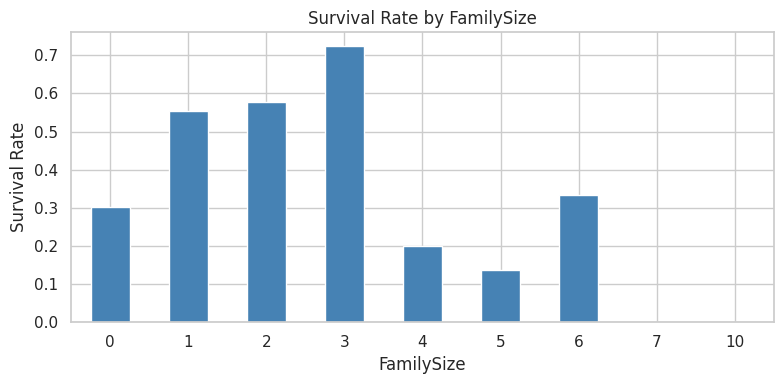

Day 2 · RF + FamilySize         CV: 0.8204 ± 0.0206
submission_day2.csv saved


In [9]:
X_tr, y_tr, X_te, feats = preprocess(train_raw, test_raw, add_family=True)

# Survival insight
_tmp = train_raw.copy()
_tmp['FamilySize'] = _tmp['SibSp'] + _tmp['Parch']
ax = _tmp.groupby('FamilySize')['Survived'].mean().plot.bar(
    figsize=(8,4), color='steelblue', rot=0,
    title='Survival Rate by FamilySize')
ax.set_ylabel('Survival Rate'); plt.tight_layout(); plt.show()

model_d2 = RandomForestClassifier(n_estimators=100, random_state=42)
score_d2 = evaluate(model_d2, X_tr, y_tr, 'Day 2 · RF + FamilySize')

model_d2.fit(X_tr, y_tr)
pd.DataFrame({'PassengerId': test_raw['PassengerId'],
              'Survived': model_d2.predict(X_te)}
             ).to_csv('submission_day2.csv', index=False)
print('submission_day2.csv saved')

## Day 3 — Title Extraction from Name
Regex-extract the passenger's title (Mr, Mrs, Miss, Master…) and consolidate rare titles.
`Title` becomes the 3rd most important feature and neatly encodes both sex and social status.

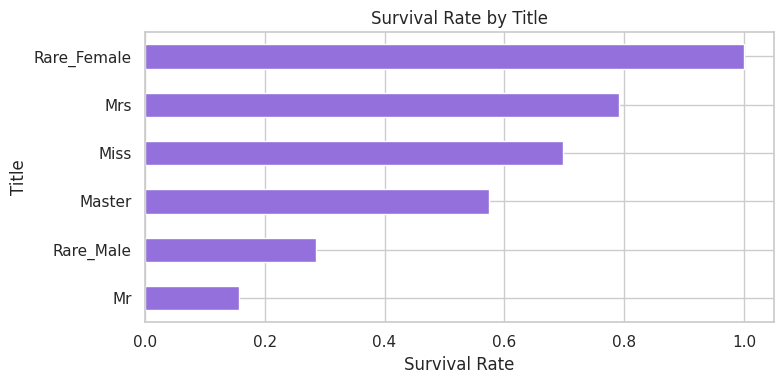

Day 3 · RF + Title              CV: 0.8204 ± 0.0181
submission_day3.csv saved


In [10]:
X_tr, y_tr, X_te, feats = preprocess(
    train_raw, test_raw, add_family=True, add_title=True)

# Survival by title
_tmp = train_raw.copy()
_tmp['Title'] = _tmp['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()
rare_male   = {'Dr','Rev','Col','Major','Capt','Jonkheer','Don','Sir'}
rare_female = {'Lady','Mme','Ms','Mlle','the Countess','Dona'}
_tmp['Title'] = _tmp['Title'].apply(
    lambda t: 'Rare_Male' if t in rare_male
              else ('Rare_Female' if t in rare_female else t))
ax = _tmp.groupby('Title')['Survived'].mean().sort_values().plot.barh(
    figsize=(8,4), color='mediumpurple', title='Survival Rate by Title')
ax.set_xlabel('Survival Rate'); plt.tight_layout(); plt.show()

model_d3 = RandomForestClassifier(n_estimators=100, random_state=42)
score_d3 = evaluate(model_d3, X_tr, y_tr, 'Day 3 · RF + Title')

model_d3.fit(X_tr, y_tr)
pd.DataFrame({'PassengerId': test_raw['PassengerId'],
              'Survived': model_d3.predict(X_te)}
             ).to_csv('submission_day3.csv', index=False)
print('submission_day3.csv saved')

## Day 4 — Logistic Regression with Feature Scaling
LR requires `StandardScaler` — without it large-range features (Fare 0–512) dominate small ones.
Coefficients are directly interpretable after scaling.

Day 4 · Logistic Regression     CV: 0.8126 ± 0.0168


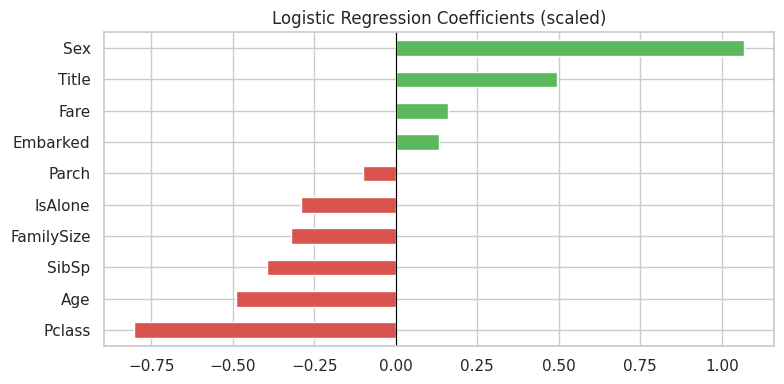

submission_day4.csv saved


In [11]:
X_tr, y_tr, X_te, feats = preprocess(
    train_raw, test_raw, add_family=True, add_title=True)

pipeline_d4 = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])
score_d4 = evaluate(pipeline_d4, X_tr, y_tr, 'Day 4 · Logistic Regression')

pipeline_d4.fit(X_tr, y_tr)

# Plot coefficients
coefs = pd.Series(pipeline_d4.named_steps['logreg'].coef_[0], index=feats).sort_values()
coefs.plot.barh(figsize=(8,4), color=['#d9534f' if v<0 else '#5cb85c' for v in coefs],
                title='Logistic Regression Coefficients (scaled)')
plt.axvline(0, color='black', lw=0.8); plt.tight_layout(); plt.show()

pd.DataFrame({'PassengerId': test_raw['PassengerId'],
              'Survived': pipeline_d4.predict(X_te)}
             ).to_csv('submission_day4.csv', index=False)
print('submission_day4.csv saved')

## Day 5 — XGBoost (Default Parameters)
Gradient boosting builds trees *sequentially*, each correcting the previous one's errors.
XGBoost places 57% of importance on `Title` alone — very different from RF's spread.

Day 5 · XGBoost default         CV: 0.8193 ± 0.0188


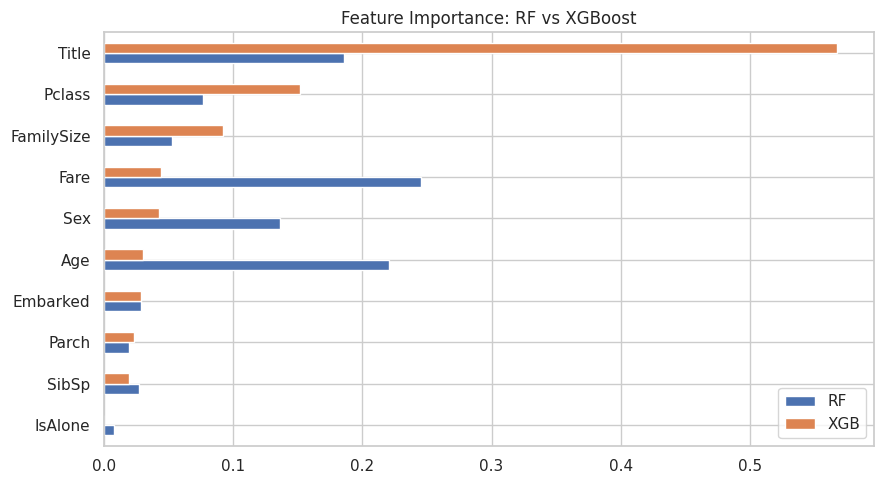

submission_day5.csv saved


In [12]:
X_tr, y_tr, X_te, feats = preprocess(
    train_raw, test_raw, add_family=True, add_title=True)

model_d5 = XGBClassifier(n_estimators=100, random_state=42,
                          eval_metric='logloss', verbosity=0)
score_d5 = evaluate(model_d5, X_tr, y_tr, 'Day 5 · XGBoost default')

model_d5.fit(X_tr, y_tr)

# Feature importance comparison
rf_tmp = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr, y_tr)
fi_df = pd.DataFrame({
    'RF':  rf_tmp.feature_importances_,
    'XGB': model_d5.feature_importances_
}, index=feats).sort_values('XGB', ascending=True)
fi_df.plot.barh(figsize=(9,5), title='Feature Importance: RF vs XGBoost')
plt.tight_layout(); plt.show()

pd.DataFrame({'PassengerId': test_raw['PassengerId'],
              'Survived': model_d5.predict(X_te)}
             ).to_csv('submission_day5.csv', index=False)
print('submission_day5.csv saved')

## Day 6 — AgeGroup Binning
Bin `Age` into Child (0–12), YoungAdult (13–25), Adult (26–60), Senior (61+).
Key finding: gender gap in survival begins at age 13 — male teenagers were treated as adults.

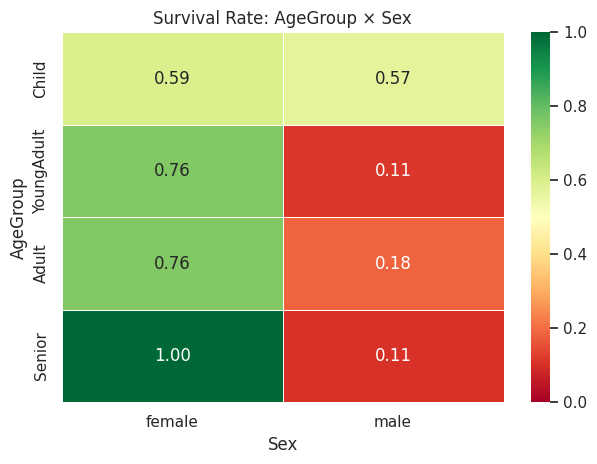

Day 6 · RF + AgeGroup           CV: 0.8182 ± 0.0129
submission_day6.csv saved


In [13]:
X_tr, y_tr, X_te, feats = preprocess(
    train_raw, test_raw, add_family=True, add_title=True, add_agegroup=True)

# AgeGroup × Sex heatmap
_tmp = train_raw.copy()
_tmp['AgeGroup'] = pd.cut(_tmp['Age'].fillna(_tmp['Age'].median()),
                           bins=[0,12,25,60,100],
                           labels=['Child','YoungAdult','Adult','Senior'])
pivot = _tmp.groupby(['AgeGroup','Sex'])['Survived'].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, vmin=0, vmax=1)
plt.title('Survival Rate: AgeGroup × Sex'); plt.tight_layout(); plt.show()

model_d6 = RandomForestClassifier(n_estimators=100, random_state=42)
score_d6 = evaluate(model_d6, X_tr, y_tr, 'Day 6 · RF + AgeGroup')

model_d6.fit(X_tr, y_tr)
pd.DataFrame({'PassengerId': test_raw['PassengerId'],
              'Survived': model_d6.predict(X_te)}
             ).to_csv('submission_day6.csv', index=False)
print('submission_day6.csv saved')

## Summary & Scoreboard

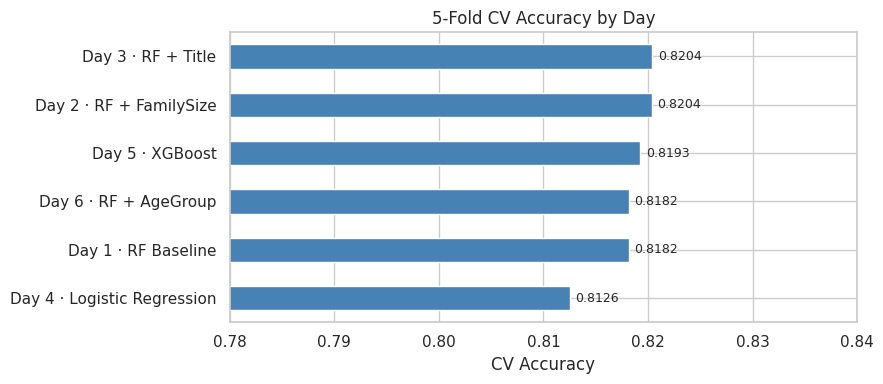


Best day: Day 3 · RF + Title


In [14]:
results = {
    'Day 1 · RF Baseline':        score_d1,
    'Day 2 · RF + FamilySize':    score_d2,
    'Day 3 · RF + Title':         score_d3,
    'Day 4 · Logistic Regression':score_d4,
    'Day 5 · XGBoost':            score_d5,
    'Day 6 · RF + AgeGroup':      score_d6,
}

ax = pd.Series(results).sort_values().plot.barh(
    figsize=(9, 4), color='steelblue',
    title='5-Fold CV Accuracy by Day')
ax.set_xlabel('CV Accuracy')
ax.set_xlim(0.78, 0.84)
for i, v in enumerate(pd.Series(results).sort_values()):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nBest day:', max(results, key=results.get))

## Next Steps (Days 7–30)

| Day | Technique |
|-----|-----------|
| 7   | `FarePerPerson = Fare / (FamilySize + 1)` |
| 8   | GridSearchCV hyperparameter tuning on RF |
| 9   | GridSearchCV hyperparameter tuning on XGBoost |
| 10  | VotingClassifier (RF + LR + XGB) |
| 11  | Deck extraction from Cabin |
| 12  | Feature selection via importance threshold |
| 13  | GradientBoostingClassifier |
| 14  | SVC with RBF kernel |
| 15  | RF-based Age imputation |
| 16  | Polynomial features |
| 17  | MLPClassifier (neural net) |
| 18  | Scale all features before all models |
| 19  | StackingClassifier |
| 20  | Sex × Age interaction features |
| 21  | XGBoost advanced hyperparameters |
| 22  | AdaBoost |
| 23  | Cross-val model selection |
| 24  | `CabinKnown` flag |
| 25  | LightGBM |
| 26  | CatBoost |
| 27  | Drop bottom-20% features by importance |
| 28  | Weighted ensemble by CV score |
| 29  | Extensive final hyperparameter tuning |
| 30  | Best model — final submission |
